In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [2]:
insurance_data = pd.read_csv("01_insurance.csv")

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#Create useful and interacted features
X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region", "sex", "smoker"], drop_first = True, dtype = int)
#Creating new features

X["bmi_smoker"] = X["bmi"] * X["smoker_yes"]
X["age_smoker"] = X["age"] * X["smoker_yes"]
X.head()

,age,bmi,children,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes,bmi_smoker,age_smoker
0,19,27.900,0,0,0,1,0,1,27.9,19
1,18,33.770,1,0,1,0,1,0,0.0,0
2,28,33.000,3,0,1,0,1,0,0.0,0
3,33,22.705,0,1,0,0,1,0,0.0,0
4,32,28.880,0,1,0,0,1,0,0.0,0


In [5]:
#Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
#Lasso Model
alpha = [0.0001,0.1,1,2,3,4,5,10,20,30,40,50,100]
error_list = []
for i in alpha:
    lasso_model = Lasso(alpha = i)
    lasso_model.fit(X_train,y_train)
    #prediction
    y_predict = lasso_model.predict(X_test)
    #mean square error
    error = mean_squared_error(y_test,y_predict)
    print(f"Mean Square Error alpha{i}:",error)
    error_list.append(error)

Mean Square Error alpha0.0001: 20922607.13250712
Mean Square Error alpha0.1: 20921805.50499951
Mean Square Error alpha1: 20914845.113596547
Mean Square Error alpha2: 20907838.778712805
Mean Square Error alpha3: 20901335.241555642
Mean Square Error alpha4: 20895388.31904298
Mean Square Error alpha5: 20890026.89075958
Mean Square Error alpha10: 20871740.05367132
Mean Square Error alpha20: 20877588.655812766
Mean Square Error alpha30: 20938007.950547285
Mean Square Error alpha40: 21047469.365479127
Mean Square Error alpha50: 21198174.0881585
Mean Square Error alpha100: 22424440.05291061


<Axes: >

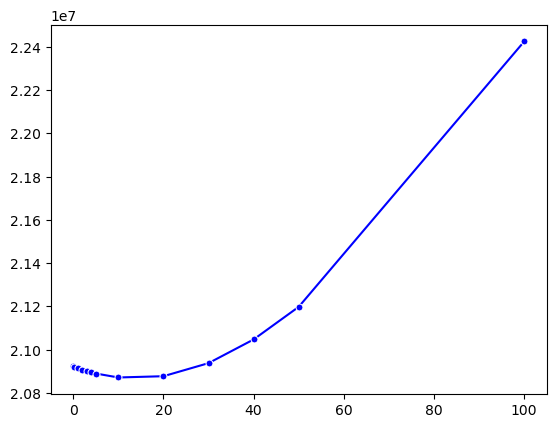

In [7]:
sns.lineplot(
    x = alpha,
    y = error_list,
    marker = ".",
    markersize=10,
    color = "blue"
)

In [8]:
#using lassCV model
from  sklearn.linear_model import LassoCV
alpha = [0.0001,0.1,1,2,3,4,5,10,20,30,40,50,100]

lassocv_model = LassoCV(
    alphas = alpha,
    cv= 5,
    max_iter = 1000,
    random_state = 42
)
lassocv_model.fit(X_train,y_train)
print("Best alpha:",lassocv_model.alpha_)

Best alpha: 0.0001


In [9]:
#prediction
y_predict = lassocv_model.predict(X_test)
#mean square error
error = mean_squared_error(y_test,y_predict)
print("Mean Square Error alpha:",error)

Mean Square Error alpha: 20922607.13250712
